# GPU usage by topic (SPECTER2 + BERTopic overlay)

Fine-grained successor to the field-level analysis: overlays GPU usage onto the
unsupervised abstract-topic clusters (stage E1/E2). Answers *which research
problems* ride which hardware.

**Kernel:** Python (accelscan). Launch Jupyter from a shell with S3 creds
exported (`set -a; source .env; set +a`).

**Confidence tiers:** clustering left ~41% of papers as HDBSCAN noise, reassigned
to nearest topic by embedding cosine (`was_outlier=True`). `CORE_ONLY` below
restricts to the density core (`was_outlier=False`) — the high-confidence view;
flip it off for full coverage as a robustness check.

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from accelscan.config import BUCKET, OUT_PREFIX, PAPERS_PREFIX
from accelscan.normalize import canonicalize_column
from accelscan.registry import load_registry
from accelscan.s3 import storage_options
from accelscan.plotting import install_year_tick_fix

install_year_tick_fix()   # no fractional year ticks (2007.5) on any figure

## Global knobs

In [2]:
CLUSTER_VERSION = 'specter2-base-mcs50-ms5-ro'   # clusters/{version}/ on S3
MODEL_TAG = 'qwen3-14b'
PROMPT_VERSION = 'p1'

# Usage contexts counted for the GPU overlay (what hardware the paper used).
USAGE_CONTEXTS: list[str] | None = ['used-in-this-work']
CORE_ONLY = True            # True = density core only (was_outlier=False)
MIN_TOPIC_GPU_PAPERS = 30   # topics need at least this many model-specific papers to rank
TOP_N = 15

MFR_COLOR = {'nvidia': '#76B900', 'amd': '#ED1C24', 'other': '#999999'}
SEG_COLOR = {'datacenter-gpu': '#0072B2', 'consumer-gpu': '#D55E00',
             'workstation-gpu': '#009E73', 'other': '#BBBBBB'}

## Load clusters, mentions, paper metadata, registry vintage

In [3]:
reg = load_registry()
so = storage_options()
cl = f's3://{BUCKET}/{OUT_PREFIX}/clusters/{CLUSTER_VERSION}'

assignments = pl.read_parquet(f'{cl}/assignments.parquet', storage_options=so)
topics = pl.read_parquet(f'{cl}/topics.parquet', storage_options=so)
if CORE_ONLY:
    assignments = assignments.filter(~pl.col('was_outlier'))
print(f'{assignments.height:,} paper-topic assignments '
      f'({"core only" if CORE_ONLY else "full incl. reassigned"}) | {topics.height} topics')

# mentions -> canonical model identity
m = (pl.scan_parquet(f's3://{BUCKET}/{OUT_PREFIX}/mentions/{reg.version}'
                     f'/{PROMPT_VERSION}/{MODEL_TAG}/parts/*.parquet', storage_options=so)
     .filter(pl.col('status') == 'ok')
     .select('corpusid', 'manufacturer', 'model_normalized', 'accelerator_subtype', 'usage_context')
     .collect())
if USAGE_CONTEXTS is not None:
    m = m.filter(pl.col('usage_context').is_in(USAGE_CONTEXTS))
m = canonicalize_column(m, reg)

# paper year (metadata table is text-free -> a plain filtered scan is fine)
ids = assignments['corpusid'].unique().to_list()
year = (pl.scan_parquet(f's3://{BUCKET}/{PAPERS_PREFIX}*.parquet', storage_options=so)
        .select('corpusid', 'year').filter(pl.col('corpusid').is_in(ids)).collect())

# registry release year per canonical model -> hardware vintage
rel = {mid: int(mm.release[:4]) for mid, mm in reg.models.items() if mm.release}
df = (m.join(assignments.select('corpusid', 'topic_id'), on='corpusid', how='inner')
       .join(year, on='corpusid', how='left')
       .with_columns(release_year=pl.col('canonical_model').replace_strict(rel, default=None,
                                                                          return_dtype=pl.Int32))
       .with_columns(hw_age=(pl.col('year') - pl.col('release_year'))))
print(f'{df.height:,} topic-attributed mentions | {df.n_unique("corpusid"):,} papers')

197,276 paper-topic assignments (core only) | 907 topics
276,631 topic-attributed mentions | 155,205 papers


## Topic overview (largest topics + keywords)

In [4]:
kw = dict(zip(topics['topic_id'].to_list(), topics['keywords'].to_list()))
overview = (df.filter(pl.col('canonical_kind') == 'model')
            .group_by('topic_id').agg(gpu_papers=pl.col('corpusid').n_unique())
            .filter(pl.col('topic_id') != -1)
            .sort('gpu_papers', descending=True)
            .with_columns(keywords=pl.col('topic_id').replace_strict(kw, default='')))
print('Top 25 topics by model-specific GPU papers:')
with pl.Config(fmt_str_lengths=80, tbl_rows=25):
    print(overview.head(25))

Top 25 topics by model-specific GPU papers:
shape: (25, 3)
┌──────────┬────────────┬──────────────────────────────────────────────────────────────────────────┐
│ topic_id ┆ gpu_papers ┆ keywords                                                                 │
│ ---      ┆ ---        ┆ ---                                                                      │
│ i32      ┆ u32        ┆ str                                                                      │
╞══════════╪════════════╪══════════════════════════════════════════════════════════════════════════╡
│ 0        ┆ 1635       ┆ code, software, code generation, vulnerability, bugs, bug, developers,   │
│          ┆            ┆ program, …                                                               │
│ 1        ┆ 1620       ┆ clinical, medical, biomedical, notes, ehr, patient, healthcare, health,  │
│          ┆            ┆ records,…                                                                │
│ 3        ┆ 1248       ┆ graph,

## Frontier-lag by topic (headline)

Median hardware age (paper year - model release year) over model-specific
mentions, per topic. **Low = riding recent hardware / near the frontier; high =
stagnating on old cards.** Restricted to topics with enough model-specific
papers to be stable.

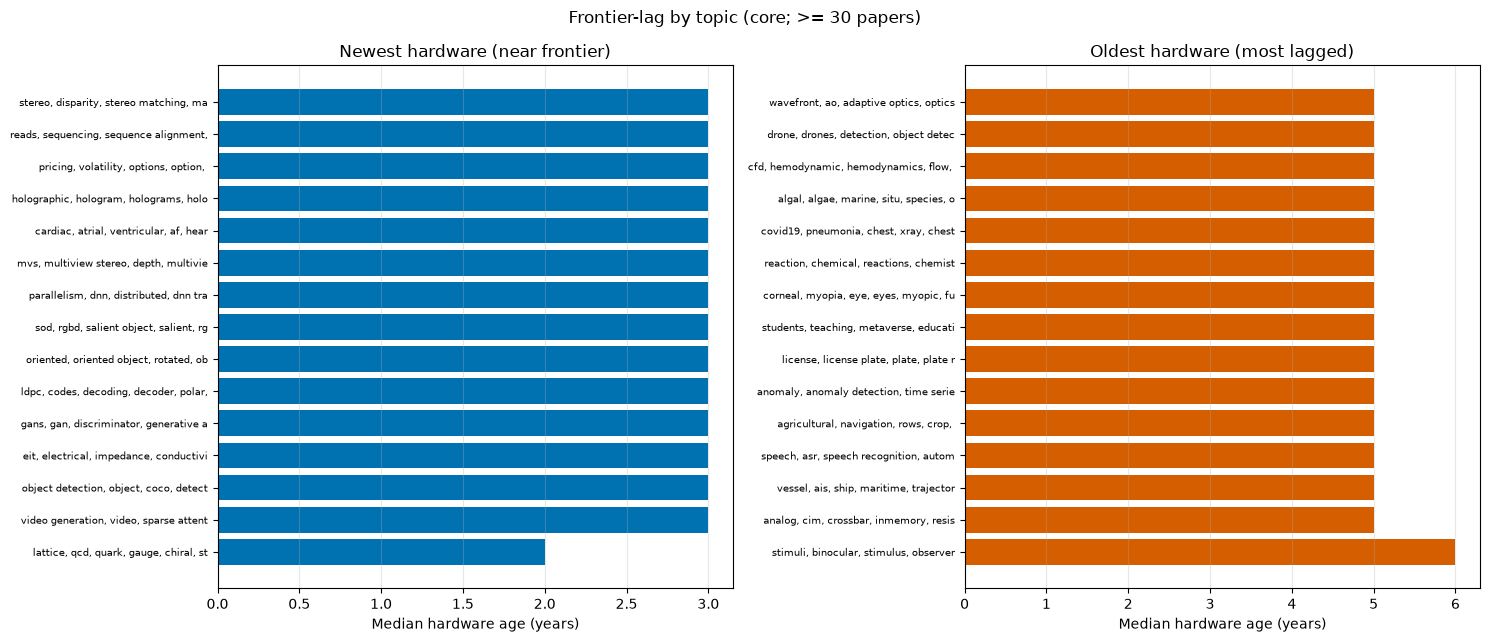

In [5]:
vint = (df.filter((pl.col('canonical_kind') == 'model') & pl.col('hw_age').is_not_null()
                  & (pl.col('topic_id') != -1))
        .select('topic_id', 'corpusid', 'canonical_model', 'hw_age').unique()
        .group_by('topic_id')
        .agg(median_age=pl.col('hw_age').median(), n=pl.col('corpusid').n_unique())
        .filter(pl.col('n') >= MIN_TOPIC_GPU_PAPERS)
        .with_columns(keywords=pl.col('topic_id').replace_strict(kw, default='')))
lo = vint.sort('median_age').head(TOP_N)                     # frontier-riding
hi = vint.sort('median_age', descending=True).head(TOP_N)    # stagnating

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, sub, title, color, desc in [
        (axes[0], lo, 'Newest hardware (near frontier)', '#0072B2', False),
        (axes[1], hi, 'Oldest hardware (most lagged)', '#D55E00', True)]:
    sub = sub.sort('median_age', descending=desc)
    ax.barh(range(sub.height), sub['median_age'], color=color)
    ax.set_yticks(range(sub.height))
    ax.set_yticklabels([k[:38] for k in sub['keywords']], fontsize=7)
    ax.set_xlabel('Median hardware age (years)'); ax.set_title(title)
    ax.grid(alpha=0.3, axis='x')
fig.suptitle(f'Frontier-lag by topic ({"core" if CORE_ONLY else "full"}; '
             f'>= {MIN_TOPIC_GPU_PAPERS} papers)')
fig.tight_layout(); plt.show()

## Manufacturer composition per topic (top topics by GPU papers)

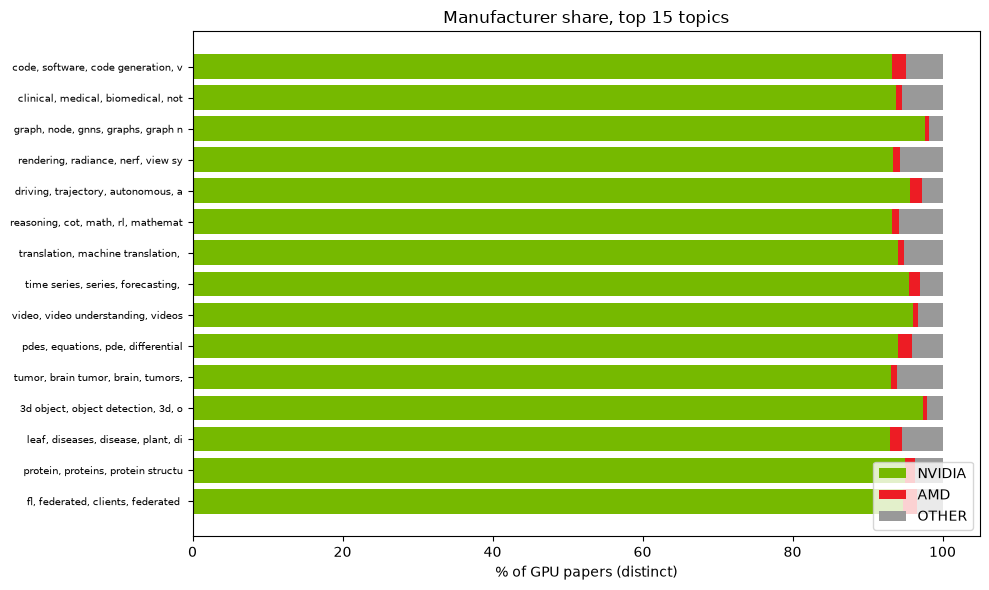

In [6]:
top_topics = overview.head(TOP_N)['topic_id'].to_list()
labels = [kw.get(t, str(t))[:34] for t in top_topics]
d = (df.filter(pl.col('manufacturer').is_in(['nvidia', 'amd', 'other'])
               & pl.col('topic_id').is_in(top_topics))
     .select('topic_id', 'corpusid', 'manufacturer').unique())
counts = d.group_by('topic_id', 'manufacturer').agg(n=pl.col('corpusid').n_unique())
tot = {t: counts.filter(pl.col('topic_id') == t)['n'].sum() for t in top_topics}
fig, ax = plt.subplots(figsize=(10, 6))
left = np.zeros(len(top_topics))
for mfr in ['nvidia', 'amd', 'other']:
    vals = []
    for t in top_topics:
        row = counts.filter((pl.col('topic_id') == t) & (pl.col('manufacturer') == mfr))
        vals.append(100 * (row['n'][0] if row.height else 0) / max(tot[t], 1))
    ax.barh(range(len(top_topics)), vals, left=left, label=mfr.upper(), color=MFR_COLOR[mfr])
    left += np.array(vals)
ax.set_yticks(range(len(top_topics))); ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('% of GPU papers (distinct)'); ax.legend(loc='lower right')
ax.set_title(f'Manufacturer share, top {TOP_N} topics'); ax.invert_yaxis()
fig.tight_layout(); plt.show()

## Segment split per topic (datacenter vs consumer vs workstation)

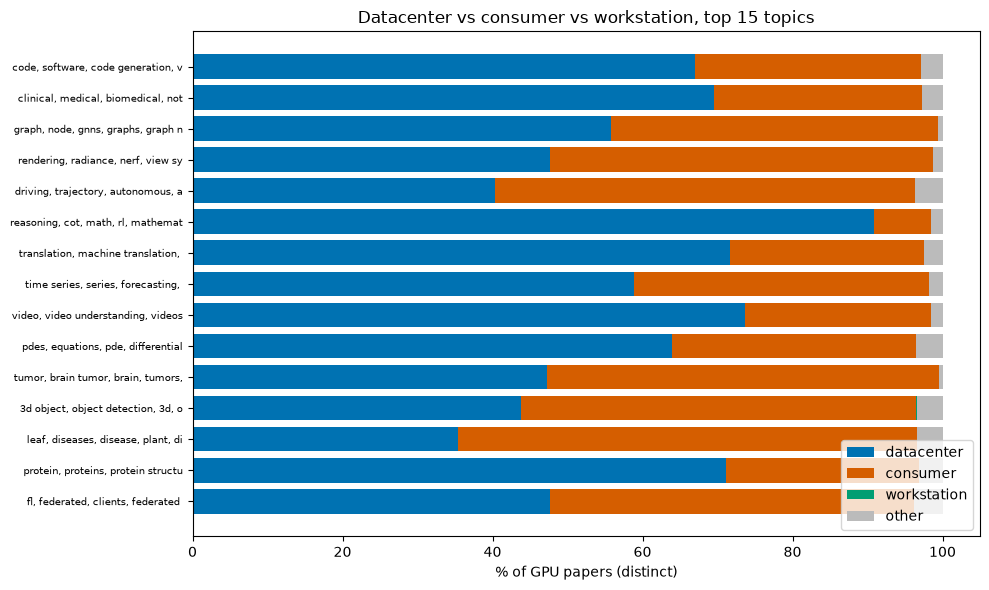

In [7]:
seg = (df.filter((pl.col('canonical_kind') == 'model') & pl.col('topic_id').is_in(top_topics))
       .with_columns(seg=pl.when(pl.col('accelerator_subtype').is_in(
           ['datacenter-gpu', 'consumer-gpu', 'workstation-gpu']))
           .then(pl.col('accelerator_subtype')).otherwise(pl.lit('other')))
       .select('topic_id', 'corpusid', 'seg').unique())
sc = seg.group_by('topic_id', 'seg').agg(n=pl.col('corpusid').n_unique())
tot = {t: sc.filter(pl.col('topic_id') == t)['n'].sum() for t in top_topics}
fig, ax = plt.subplots(figsize=(10, 6))
left = np.zeros(len(top_topics))
for s in ['datacenter-gpu', 'consumer-gpu', 'workstation-gpu', 'other']:
    vals = []
    for t in top_topics:
        row = sc.filter((pl.col('topic_id') == t) & (pl.col('seg') == s))
        vals.append(100 * (row['n'][0] if row.height else 0) / max(tot[t], 1))
    ax.barh(range(len(top_topics)), vals, left=left, label=s.replace('-gpu', ''), color=SEG_COLOR[s])
    left += np.array(vals)
ax.set_yticks(range(len(top_topics))); ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('% of GPU papers (distinct)'); ax.legend(loc='lower right')
ax.set_title(f'Datacenter vs consumer vs workstation, top {TOP_N} topics'); ax.invert_yaxis()
fig.tight_layout(); plt.show()